In [2]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import os
import warnings
warnings.filterwarnings('ignore')

#loading the data file and turing the sorted date to index.
import sys
sys.path.append(os.path.abspath('..'))
from scripts.data_loader import MacroDataLoader

loader = MacroDataLoader('../data/master_data1.csv')
loader.load()
df =loader.df


In [3]:
#checking the data
print(df.columns.to_list())
print(df.isnull().sum())

['iip', 'm3', 'repo_rate', 'tbill_91d', 'gsec_10yr', 'inr_usd', 'cpi_inflation', 'fed_funds_rate', 'crude_oil_brent', 'term_spread']
iip                0
m3                 0
repo_rate          0
tbill_91d          0
gsec_10yr          0
inr_usd            0
cpi_inflation      0
fed_funds_rate     0
crude_oil_brent    0
term_spread        0
dtype: int64


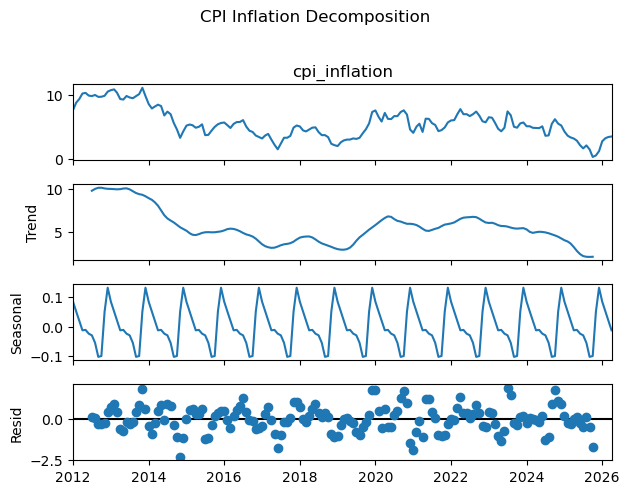

In [4]:
# running decompostion on CPI to observe its trend, seasonality and redual
decomposition = seasonal_decompose(df['cpi_inflation'], model='additive', period=12)
decomposition.plot()
plt.suptitle('CPI Inflation Decomposition', y=1.02)
plt.tight_layout()
plt.show()

In [6]:
#Running a ADF and KPSS test on all the variable.

loader.run_stationarity_tests()
print(loader.stationarity_results)

          variable  adf_pvalue  kpss_pvalue  adf_stationary  kpss_staionary
0    cpi_inflation      0.2472       0.0129           False           False
1        repo_rate      0.4502       0.0100           False           False
2               m3      0.0064       0.1000            True            True
3  crude_oil_brent      0.0932       0.1000           False            True
4          inr_usd      0.8185       0.0100           False           False
5              iip      0.0000       0.1000            True            True
6        tbill_91d      0.4638       0.0100           False           False
7        gsec_10yr      0.2319       0.0100           False           False
8      term_spread      0.2692       0.0100           False           False
9   fed_funds_rate      0.3046       0.0100           False           False


## Final Lag Structure — SHAP Validated

| Variable        | Lag | Reason                              |
|----------------|-----|-------------------------------------|
| CPI inflation  | 1,2,3 | AR(3) momentum                    |
| Crude oil      | 1   | Fast supply shock transmission      |
| INR/USD        | 1   | Quick exchange rate pass through    |
| M3             | 12  | Slow monetary transmission — P1     |

In [8]:
#implementing the Lag feature.
loader.build_lag_features()
print(loader.feature_matrix.shape)
print('===='*20)
print(loader.feature_matrix.columns.to_list())
      

(160, 16)
['iip', 'm3', 'repo_rate', 'tbill_91d', 'gsec_10yr', 'inr_usd', 'cpi_inflation', 'fed_funds_rate', 'crude_oil_brent', 'term_spread', 'cpi_lag1', 'cpi_lag2', 'cpi_lag3', 'crude_lag1', 'inr_lag1', 'm3_lag12']


In [9]:
#feature matrix
X,y =loader.get_feature_matrix()
print(X.shape , y.shape)


(160, 6) (160,)


## Stationarity Notebook — Summary

**Stationarity Status**
- Stationary — IIP, M3
- Non-Stationary — repo rate, T-bill, G-Sec, INR/USD, crude oil
- Borderline — CPI inflation (rate series, treated as stationary for ARIMA)

**Differencing Decision**
- INR/USD and crude oil confirmed non-stationary
- Differencing not applied to feature matrix
- XGBoost is tree based — stationarity not required
- ARIMAX exog variables use lagged levels — same reasoning

**Final Feature Matrix**
- 6 features — CPI lag 1,2,3 | crude lag 1 | INR lag 1 | M3 lag 12
- 160 observations after dropping nulls
- Test window — January 2022 onwards
- Lag selection validated by SHAP in notebook 06